# Latin hypercube vs Monte Carlo

At small `n` relative to the problem's dimensionality, plain Monte Carlo gives uneven coverage of each axis just by chance. Latin hypercube sampling stratifies each axis into `n` equal-probability bins by construction, so every axis sees one sample per bin regardless of `n`. This notebook makes that contrast visible: 64 Latin hypercube runs and 64 Monte Carlo runs against the same 4-axis injection perturbation, with the unit-cube samples in a pair plot to show the stratification and the resulting miss-distance distributions stacked to show the variance reduction.

**Prerequisites.** A local GMAT install (R2026a is the primary development target; see [Supported versions](https://astro-tools.github.io/gmat-sweep/supported-versions/)) and `pip install gmat-sweep[examples]` for the matplotlib dependency.

## Set up the run

Same fixture as [notebook 04](https://astro-tools.github.io/gmat-sweep/examples/04_monte_carlo_dispersion/) — a parking orbit, an injection burn `Inj` in VNB, a `CoastTime` variable for the parking-orbit phase, and a fixed post-burn propagation.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from gmat_run import locate_gmat
from scipy.stats import qmc

from gmat_sweep import latin_hypercube, monte_carlo

install = locate_gmat()
script_path = Path("injection_dispersion.script").resolve()

print(f"GMAT version: {install.version}")
print(f"Script:       {script_path.name}")
print(f"Exists:       {script_path.exists()}")

GMAT version: R2026a
Script:       injection_dispersion.script
Exists:       True


## Define the 4-axis perturbation cube

Four independent axes — same shape as [notebook 04](https://astro-tools.github.io/gmat-sweep/examples/04_monte_carlo_dispersion/), so the contrast is purely about how the samples are drawn:

- `CoastTime.Value` — normal, mean 600 s, 1-sigma 30 s.
- `Inj.Element1/2/3` — normal, mean (1.0, 0.0, 0.0) km/s, 1-sigma 5 m/s on each axis.

In [2]:
SEED = 20260505
N = 64

perturb = {
    "CoastTime.Value": ("normal", 600.0, 30.0),
    "Inj.Element1": ("normal", 1.0, 0.005),
    "Inj.Element2": ("normal", 0.0, 0.005),
    "Inj.Element3": ("normal", 0.0, 0.005),
}

# `latin_hypercube()` sorts perturb keys lexicographically internally,
# so we mirror that order here for the column labels on the pair plot.
axis_labels = sorted(perturb)

## Stratification, visually

Draw `n=64` unit-cube samples from a Latin hypercube on `d=4` and `n=64` samples from a plain pseudo-random uniform on the same hypercube. Every Latin hypercube column has exactly one sample per `1/n`-wide bin; the pseudo-random columns do not.

The pair plot below shows two of the four axes against each other for both methods. The Latin hypercube panel shows a marginal grid pattern: every horizontal and every vertical strip carries exactly one point. The Monte Carlo panel shows clustering and gaps — the law of large numbers fixes that, but only at much larger `n`.

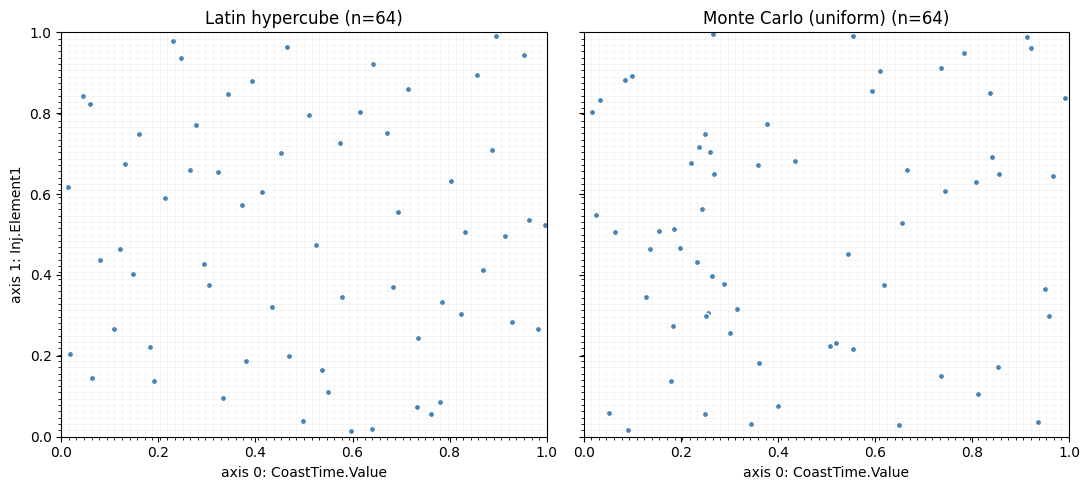

In [3]:
lh_unit = qmc.LatinHypercube(d=len(perturb), seed=SEED).random(n=N)
mc_unit = np.random.default_rng(SEED).uniform(size=(N, len(perturb)))

i, j = 0, 1  # any two of the four axes
fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharex=True, sharey=True)
for ax, samples, title in (
    (axes[0], lh_unit, "Latin hypercube"),
    (axes[1], mc_unit, "Monte Carlo (uniform)"),
):
    bins = np.arange(0.0, 1.0 + 1e-9, 1.0 / N)
    ax.set_xticks(bins, minor=True)
    ax.set_yticks(bins, minor=True)
    ax.grid(which="minor", alpha=0.2, linewidth=0.4)
    ax.scatter(samples[:, i], samples[:, j], s=20, color="steelblue", edgecolor="white")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_title(f"{title} (n={N})")
    ax.set_xlabel(f"axis {i}: {axis_labels[i]}")
axes[0].set_ylabel(f"axis {j}: {axis_labels[j]}")
fig.tight_layout()
plt.show()

## Run both sweeps

[`latin_hypercube()`](https://astro-tools.github.io/gmat-sweep/api/#gmat_sweep.latin_hypercube) and [`monte_carlo()`](https://astro-tools.github.io/gmat-sweep/api/#gmat_sweep.monte_carlo) share their public surface — same script, same perturb, same `n`, same seed. The only difference is how the per-run draws come out of the unit cube before being mapped through each distribution's quantile function.

In [4]:
df_lh = latin_hypercube(script_path, n=N, perturb=perturb, seed=SEED, progress=False)
df_mc = monte_carlo(script_path, n=N, perturb=perturb, seed=SEED, progress=False)

print("LH status counts:")
print(df_lh["__status"].value_counts())
print("\nMC status counts:")
print(df_mc["__status"].value_counts())

LH status counts:
__status
ok    768
Name: count, dtype: int64

MC status counts:
__status
ok    767
Name: count, dtype: int64


## Arrival-cloud spread comparison

For each method, take the final-step row per run, compute the miss distance to the method's own mean arrival point, and stack the two distributions. The Latin hypercube histogram is tighter and more centred — the variance-reduction case is visible at the same `n`.

The two methods estimate the *same* underlying dispersion, so the means line up. The spread of empirical estimators (the histogram tails) is what improves with stratification.

LH miss distance: mean=216.034 km, std=164.645 km
MC miss distance: mean=238.885 km, std=179.696 km


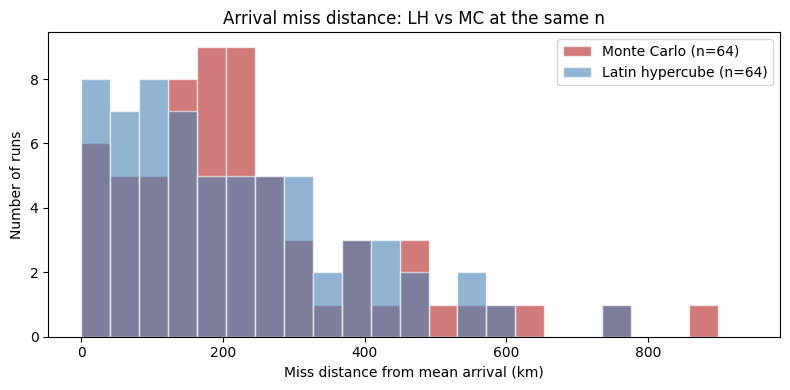

In [5]:
def miss_distances(df):
    final = df.groupby(level="run_id").last()
    arrivals = final[["Sat.X", "Sat.Y", "Sat.Z"]].to_numpy()
    return np.linalg.norm(arrivals - arrivals.mean(axis=0), axis=1)


miss_lh = miss_distances(df_lh)
miss_mc = miss_distances(df_mc)

print(f"LH miss distance: mean={miss_lh.mean():.3f} km, std={miss_lh.std():.3f} km")
print(f"MC miss distance: mean={miss_mc.mean():.3f} km, std={miss_mc.std():.3f} km")

fig, ax = plt.subplots(figsize=(8, 4))
bins = np.linspace(0.0, max(miss_lh.max(), miss_mc.max()) * 1.05, 24)
ax.hist(
    miss_mc,
    bins=bins,
    alpha=0.6,
    color="firebrick",
    edgecolor="white",
    label=f"Monte Carlo (n={N})",
)
ax.hist(
    miss_lh,
    bins=bins,
    alpha=0.6,
    color="steelblue",
    edgecolor="white",
    label=f"Latin hypercube (n={N})",
)
ax.set_xlabel("Miss distance from mean arrival (km)")
ax.set_ylabel("Number of runs")
ax.set_title("Arrival miss distance: LH vs MC at the same n")
ax.legend()
fig.tight_layout()
plt.show()

## Where to next

- **Larger samples on the same surface.** [Notebook 04](https://astro-tools.github.io/gmat-sweep/examples/04_monte_carlo_dispersion/) runs the same perturbation cube as a 1000-run Monte Carlo and walks through the histogram + 3-sigma ellipse plus the determinism contract.
- **Stratification details.** [Parameter spec → Monte Carlo vs Latin hypercube](https://astro-tools.github.io/gmat-sweep/parameter-spec/#monte-carlo-vs-latin-hypercube) documents when to reach for each.
- **Distribution shapes.** Both wrappers accept any pre-frozen [`scipy.stats`](https://docs.scipy.org/doc/scipy/reference/stats.html) distribution as a perturb value; the three shorthand tuples are an ergonomic surface, not a hard limit.